# Task 4: Modality Gap in CLIP

In this notebook, we evaluate OpenAI's CLIP model on STL-10, investigate the "Modality Gap" (separation between image and text embeddings), and attempt to bridge it using Procrustes alignment.

In [14]:
import torch
import clip
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
import json
import os

from clip_utils import (
    load_clip_model, 
    load_stl10_data, 
    evaluate_zero_shot, 
    extract_features, 
    align_embeddings, 
    get_zeroshot_classifier
)

# Setup Device
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


## 4.1 Zero-Shot Classification
We evaluate CLIP's accuracy using different prompting strategies.

In [3]:
# Load Model & Data
model, preprocess = load_clip_model(device)
dataset, loader = load_stl10_data(preprocess, split='test')
class_names = dataset.classes
print(f"Classes: {class_names}")

Loading CLIP model (ViT-B/32)...


100%|███████████████████████████████████████| 338M/338M [02:03<00:00, 2.87MiB/s]


Loading STL-10 (test split)...


100%|██████████| 2.64G/2.64G [42:21<00:00, 1.04MB/s]   


Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [ ]:
prompt_strategies = {
    "Plain": ["{}"],
    "Standard": ["a photo of a {}"],
    "Ensemble": [
        "a photo of a {}",
        "a rendering of a {}",
        "a cropped photo of the {}",
        "the photo of a {}",
        "a clean photo of a {}"
    ]
}

# Evaluate
results = {}

print("\nRunning Zero-Shot Evaluation")
for name, templates in prompt_strategies.items():
    acc = evaluate_zero_shot(model, loader, class_names, templates, device)
    results[name] = acc
    print(f"Strategy: {name:<10} | Accuracy: {acc:.2%}")


Running Zero-Shot Evaluation


Building prompt embeddings: 100%|██████████| 10/10 [00:03<00:00,  3.16it/s]


Evaluating Zero-Shot with 1 template(s)...


Inference: 100%|██████████| 250/250 [02:05<00:00,  1.99it/s]


Strategy: Plain      | Accuracy: 96.24%


...

Strategy: Standard   | Accuracy: 97.35%


Building prompt embeddings: 100%|██████████| 10/10 [00:01<00:00,  8.00it/s]


Evaluating Zero-Shot with 5 template(s)...


Inference: 100%|██████████| 250/250 [01:59<00:00,  2.09it/s]

Strategy: Ensemble   | Accuracy: 97.31%


## 4.2 Exploring the Modality Gap
We extract embeddings for a subset of the data and visualize the distribution of Image vectors vs. Text vectors.

In [16]:
# Extract features for 100 samples
img_emb, txt_emb, labels = extract_features(model, dataset, num_samples=100, device=device)

print(f"Image Embeddings shape: {img_emb.shape}")
print(f"Text Embeddings shape:  {txt_emb.shape}")

Extracting features for 100 samples...
Image Embeddings shape: (100, 512)
Text Embeddings shape:  (100, 512)


/Users/abdulhafeez/miniconda3/envs/pa5/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved plot to outputs/modality_gap/gap_before.png


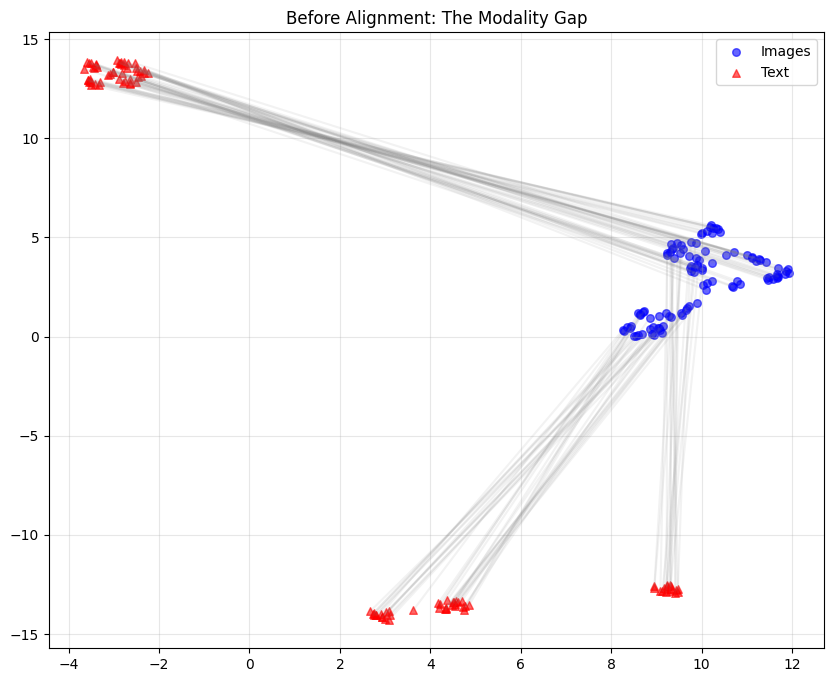

In [17]:
def visualize_gap(img_emb, txt_emb, title="Modality Gap", save_filename=None):
    combined = np.vstack([img_emb, txt_emb])
    reducer = umap.UMAP(random_state=42)
    embedding = reducer.fit_transform(combined)
    n = len(img_emb)
    img_2d = embedding[:n]
    txt_2d = embedding[n:]
    
    # Plot
    plt.figure(figsize=(10, 8))
    plt.scatter(img_2d[:, 0], img_2d[:, 1], c='blue', alpha=0.6, label='Images', s=30)
    plt.scatter(txt_2d[:, 0], txt_2d[:, 1], c='red', alpha=0.6, label='Text', marker='^', s=30)
    
    # Showing alignment
    for i in range(n):
        plt.plot([img_2d[i, 0], txt_2d[i, 0]], [img_2d[i, 1], txt_2d[i, 1]], 
                 color='gray', alpha=0.1)

    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    if save_filename:
        os.makedirs('outputs/modality_gap', exist_ok=True)
        plt.savefig(f'outputs/modality_gap/{save_filename}')
        print(f"Saved plot to outputs/modality_gap/{save_filename}")
    plt.show()

# Visualize Original Gap
visualize_gap(img_emb, txt_emb, title="Before Alignment: The Modality Gap", save_filename="gap_before.png")

## 4.3 Bridging the Modality Gap
We learn a rotation matrix $R$ to align the image embeddings to the text embeddings using Orthogonal Procrustes.

Computing Procrustes Alignment...


/Users/abdulhafeez/miniconda3/envs/pa5/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/abdulhafeez/miniconda3/envs/pa5/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


Saved plot to outputs/modality_gap/gap_after.png


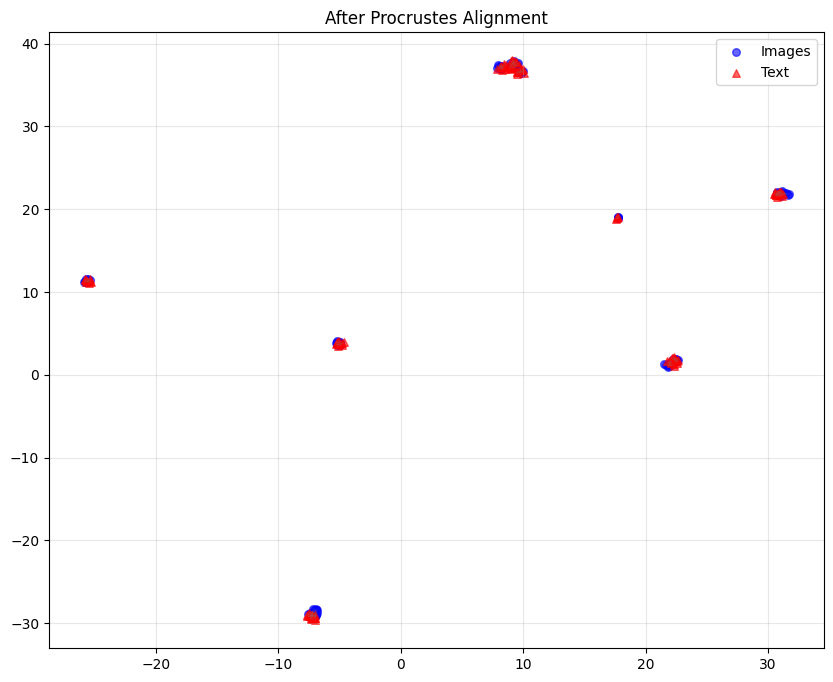

In [18]:
# 1. Learn Alignment (using the extracted subset)
R, aligned_img_emb = align_embeddings(img_emb, txt_emb)

# 2. Visualize Aligned Space
visualize_gap(aligned_img_emb, txt_emb, title="After Procrustes Alignment", save_filename="gap_after.png")

### 4.3 (f). Recompute Accuracy with Aligned Embeddings
Does geometrically aligning the spheres actually improve classification? We re-run the evaluation applying $R$ to all image features.

In [19]:
def evaluate_aligned_zero_shot(model, loader, class_names, template, R, device):
    """
    Custom evaluation loop that applies rotation R to image features before classification.
    """
    # Get Text Classifiers (Target Anchors)
    # We use the 'Standard' prompt for fair comparison
    classifier = get_zeroshot_classifier(model, class_names, [template], device)
    
    # Convert R to tensor
    R_tensor = torch.tensor(R, dtype=torch.float16).to(device) if device != 'cpu' else torch.tensor(R, dtype=torch.float32)
    
    correct = 0
    total = 0
    
    print("Evaluating Aligned Zero-Shot...")
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            # Encode Images
            img_feat = model.encode_image(images)
            img_feat /= img_feat.norm(dim=-1, keepdim=True)
            
            # Apply alignment
            # Rotate image features: X_aligned = X @ R
            # Note: Ensure data types match (CLIP uses float16 on GPU often)
            img_feat = img_feat.to(R_tensor.dtype)
            aligned_feat = img_feat @ R_tensor
            
            # Classification
            logits = 100. * aligned_feat @ classifier.to(R_tensor.dtype)
            preds = logits.argmax(dim=-1)
            
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
    return correct / total

# Run evaluation
aligned_acc = evaluate_aligned_zero_shot(
    model, 
    loader, 
    class_names, 
    template="a photo of a {}", 
    R=R, 
    device=device
)

print(f"\nOriginal Accuracy (Standard): {results['Standard']:.2%}")
print(f"Aligned Accuracy: {aligned_acc:.2%}")
print(f"Change: {aligned_acc - results['Standard']:.2%}")

Building prompt embeddings: 100%|██████████| 10/10 [00:00<00:00, 16.36it/s]


Evaluating Aligned Zero-Shot...

Original Accuracy (Standard): 97.35%
Aligned Accuracy: 97.41%
Change: 0.06%
